# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Reza Aliyya Nasution
- **Email:** rezaaliyya925@gmail.com
- **ID Dicoding:** reza_aliyya

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana rata-rata jumlah penyewaan sepeda pada setiap kategori kondisi cuaca selama tahun 2011–2012, dan kondisi mana yang menghasilkan penyewaan tertinggi?
- **Pertanyaan 2:** Pada jam berapa rata-rata penyewaan sepeda mencapai puncaknya dalam satu hari selama periode 2011–2012?
- **Pertanyaan 3:** Berapa perbedaan rata-rata jumlah penyewaan sepeda antara hari kerja dan akhir pekan selama tahun 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Data Wrangling

### Gathering Data

#### Load tabel day

In [ ]:
day_df = pd.read_csv("data/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


#### Load tabel hour

In [ ]:
hour_df = pd.read_csv("data/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Dataset terdiri dari data harian `(day_df)` dan data per jam `(hour_df)`yang memungkinkan analisis berdasarkan waktu yang berbeda.
- Terdapat variabel penting seperti kondisi cuaca `(weathersit)` dan jumlah penyewaan `(cnt)` yang berpotensi digunakan untuk menganalisis pola penggunaan sepeda.


### Assessing Data

#### Identifying Problems (Day Dataset)

In [ ]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())
day_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [ ]:
(day_df['casual'] + day_df['registered'] == day_df['cnt']).all()

np.True_

**Steps to Take:**
- Mengubah tipe data pada kolom `(dteday)` pada tabel `day` dari object ke datetime

#### Identifying Problems (Hour Dataset)

In [ ]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())
hour_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [ ]:
(hour_df['casual'] + hour_df['registered'] == hour_df['cnt']).all()

np.True_

**Steps to Take:**
- Mengubah tipe data pada kolom `(dteday)` pada tabel `hour` dari object ke datetime

### Cleaning Data

#### Fixing Data Type Issues (Day Dataset)

In [ ]:
datetime_columns = ["dteday"]

for column in datetime_columns:
  day_df[column] = pd.to_datetime(day_df[column])

In [ ]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

#### Fixing Data Type Issues (Hour Dataset)

In [ ]:
datetime_columns = ["dteday"]

for column in datetime_columns:
  hour_df[column] = pd.to_datetime(hour_df[column])

In [ ]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

### Export Cleaned Data

In [ ]:
day_df.to_csv("day_cleaned.csv", index=False)
hour_df.to_csv("hour_cleaned.csv", index=False)

## Exploratory Data Analysis (EDA)

### Explore Day Dataset

In [ ]:
day_df.groupby(by='mnth')['cnt'].mean().sort_values(ascending=False)

,cnt
mnth,
6,5772.366667
9,5766.516667
8,5664.419355
7,5563.677419
5,5349.774194
10,5199.225806
4,4484.900000
11,4247.183333
3,3692.258065


**Insight:**

Rata-rata jumlah penyewaan sepeda tertinggi terjadi pada bulan Juni, yang menunjukkan adanya peningkatan penggunaan sepeda pada pertengahan tahun.

In [ ]:
day_df.groupby(by='weathersit')['cnt'].mean().sort_values(ascending=False)

,cnt
weathersit,
1,4876.786177
2,4035.862348
3,1803.285714


**Insight:**

Kondisi cuaca cerah (weathersit = 1) memiliki rata-rata jumlah penyewaan sepeda tertinggi dibandingkan kondisi cuaca lainnya.

In [ ]:
day_df[["casual", "registered"]].mean().sort_values(ascending=False)

,0
registered,3656.172367
casual,848.176471


**Insight:**

Jumlah pengguna terdaftar (registered) secara signifikan lebih tinggi dibandingkan pengguna kasual (casual).

In [ ]:
day_df.groupby(by="workingday")["cnt"].mean()

,cnt
workingday,
0,4330.168831
1,4584.820000


**Insight:**

Rata-rata penyewaan sepeda cenderung lebih tinggi pada hari kerja dibandingkan non-working day (akhir pekan atau hari libur)

In [ ]:
day_df[["temp", "hum", "windspeed", "cnt"]].corr()

,temp,hum,windspeed,cnt
temp,1.000000,0.126963,-0.157944,0.627494
hum,0.126963,1.000000,-0.248489,-0.100659
windspeed,-0.157944,-0.248489,1.000000,-0.234545
cnt,0.627494,-0.100659,-0.234545,1.000000


**Insight:**

Terdapat korelasi positif yang cukup kuat antara suhu (temp) dan jumlah penyewaan sepeda (cnt) sebesar 0.627, yang menunjukkan bahwa semakin hangat suhu, semakin tinggi jumlah penyewaan sepeda.

In [ ]:
day_df.groupby(by="season")["cnt"].mean().sort_values(ascending=False)

,cnt
season,
3,5644.303191
2,4992.331522
4,4728.162921
1,2604.132597


**Insight:**

Musim gugur (season = 3) memiliki rata-rata jumlah penyewaan sepeda tertinggi dibandingkan musim lainnya.

### Explore Hour Dataset

In [ ]:
hour_df.groupby(by="hr")["cnt"].mean().sort_values(ascending=False).head(5)

,cnt
hr,
17,461.452055
18,425.510989
8,359.011004
16,311.983562
19,311.523352


**Insight:**

Rata-rata jumlah penyewaan sepeda tertinggi terjadi pada pukul 08.00 serta 16.00–19.00, yang menunjukkan adanya pola peak hours pada waktu berangkat dan pulang kerja.

In [ ]:
hour_df.groupby(by="workingday")["cnt"].mean()

,cnt
workingday,
0,181.405332
1,193.207754


**Insight:**

Rata-rata penyewaan sepeda lebih tinggi pada hari kerja (workingday = 1) dibandingkan akhir pekan atau hari libur, yang mengindikasikan bahwa sepeda banyak digunakan untuk aktivitas rutin seperti bekerja.

In [ ]:
hour_df.groupby(by="weathersit")["cnt"].mean()

,cnt
weathersit,
1,204.869272
2,175.165493
3,111.579281
4,74.333333


**Insight:**

Kondisi cuaca cerah (weathersit = 1) memiliki rata-rata penyewaan tertinggi, diikuti oleh kondisi cuaca yang kurang baik, menunjukkan bahwa cuaca sangat memengaruhi minat penggunaan sepeda.

In [ ]:
hour_df[["casual", "registered"]].mean()

,0
casual,35.676218
registered,153.786869


**Insight:**

Pengguna terdaftar (registered) secara konsisten memiliki jumlah penyewaan yang lebih tinggi dibandingkan pengguna kasual (casual).

In [ ]:
hour_df[["temp", "hum", "windspeed", "cnt"]].corr()

,temp,hum,windspeed,cnt
temp,1.000000,-0.069881,-0.023125,0.404772
hum,-0.069881,1.000000,-0.290105,-0.322911
windspeed,-0.023125,-0.290105,1.000000,0.093234
cnt,0.404772,-0.322911,0.093234,1.000000


**Insight:**

Terdapat korelasi positif antara suhu (temp) dan jumlah penyewaan sepeda (cnt) sebesar 0,4, meskipun hubungan ini tidak sekuat pada data harian.

In [ ]:
hour_df.groupby(by="hr")[["casual", "registered"]].mean()

,casual,registered
hr,,
0,10.158402,43.739669
1,6.504144,26.871547
2,4.772028,18.097902
3,2.715925,9.011478
4,1.253945,5.098996
5,1.411437,18.478382
6,4.161379,71.882759
7,11.055021,201.009629
8,21.679505,337.331499


**Insight:**

- Pengguna terdaftar (registered) mendominasi pada jam sibuk, terutama pukul 07.00–09.00 dan 16.00–18.00, yang menunjukkan pola penggunaan untuk aktivitas komuter (berangkat dan pulang kerja).
- Sebaliknya, pengguna kasual (casual) cenderung lebih aktif pada siang hingga sore hari (sekitar pukul 11.00–15.00), yang mengindikasikan penggunaan untuk aktivitas rekreasi atau santai.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana rata-rata jumlah penyewaan sepeda pada setiap kategori kondisi cuaca selama tahun 2011–2012, dan kondisi mana yang menghasilkan penyewaan tertinggi?

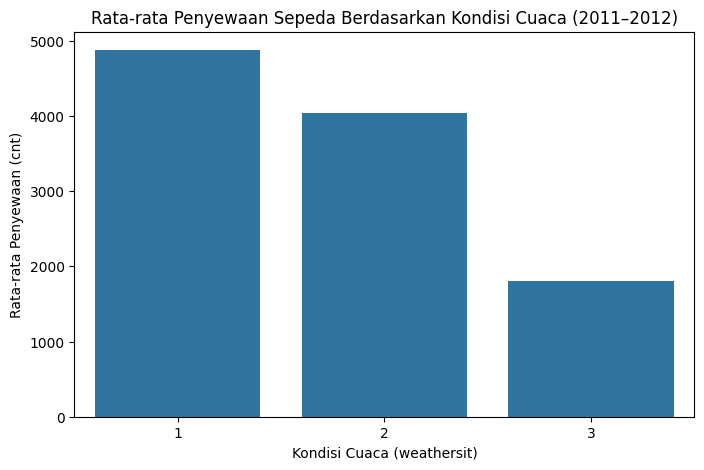

In [ ]:
weather_avg = day_df.groupby("weathersit")["cnt"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=weather_avg, x="weathersit", y="cnt")

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca (2011–2012)")
plt.xlabel("Kondisi Cuaca (weathersit)")
plt.ylabel("Rata-rata Penyewaan (cnt)")
plt.show()

**Insight:**
- Rata-rata penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah (weathersit = 1) dan menurun seiring memburuknya kondisi cuaca.
- Hal ini menunjukkan adanya hubungan yang jelas antara kondisi cuaca dan tingkat penyewaan sepeda.

### Pertanyaan 2: Pada jam berapa rata-rata penyewaan sepeda mencapai puncaknya dalam satu hari selama periode 2011–2012?

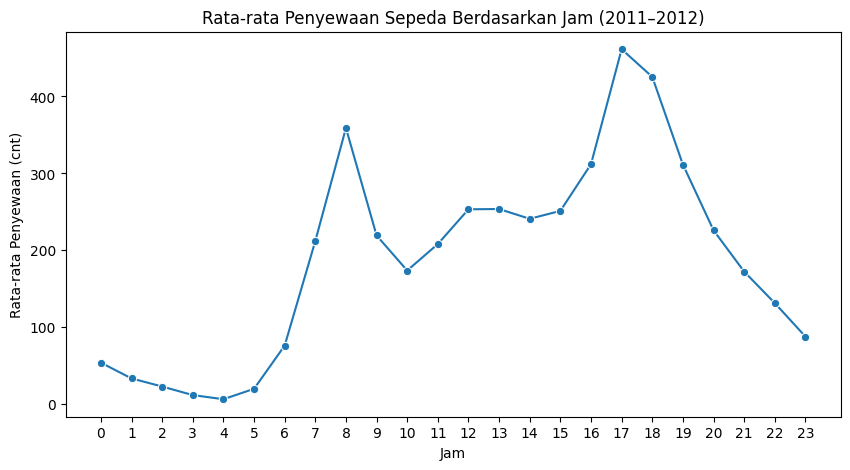

In [ ]:
hour_avg = hour_df.groupby("hr")["cnt"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=hour_avg, x="hr", y="cnt", marker="o")

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Jam (2011–2012)")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan (cnt)")
plt.xticks(range(0,24))
plt.show()

**Insight:**

- Penyewaan sepeda mencapai puncaknya pada pukul 08.00 serta 16.00–18.00.
- Pola ini menunjukkan adanya dua periode puncak dalam sehari yang konsisten

### Pertanyaan 3: Berapa perbedaan rata-rata jumlah penyewaan sepeda antara hari kerja dan akhir pekan selama tahun 2011–2012?

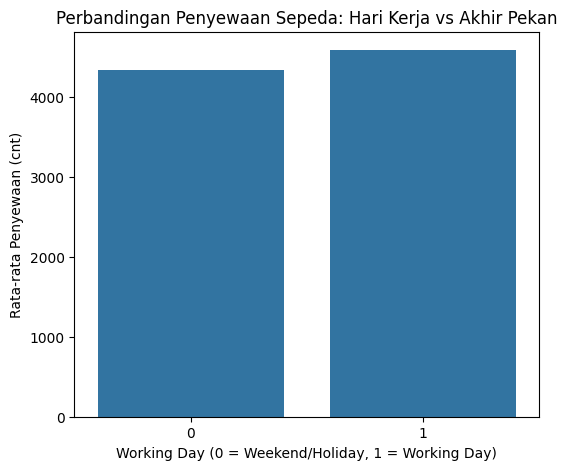

In [ ]:
workingday_avg = day_df.groupby("workingday")["cnt"].mean().reset_index()

plt.figure(figsize=(6,5))
sns.barplot(data=workingday_avg, x="workingday", y="cnt")

plt.title("Perbandingan Penyewaan Sepeda: Hari Kerja vs Akhir Pekan")
plt.xlabel("Working Day (0 = Weekend/Holiday, 1 = Working Day)")
plt.ylabel("Rata-rata Penyewaan (cnt)")
plt.show()

**Insight:**

- Rata-rata penyewaan sepeda lebih tinggi pada hari kerja dibandingkan akhir pekan atau hari libur.
- Hal ini menunjukkan adanya perbedaan pola penggunaan sepeda berdasarkan jenis hari.

## Analisis Lanjutan (Opsional)

### Clustering Berdasarkan Tingkat Permintaan

Pada tahap ini dilakukan pengelompokan data berdasarkan tingkat permintaan penyewaan sepeda menggunakan metode binning (quantile). Data dibagi menjadi tiga kategori, yaitu Low, Medium, dan High berdasarkan distribusi jumlah penyewaan (cnt).

In [ ]:
# Membuat kategori demand berdasarkan quantile
day_df['demand_category'] = pd.qcut(
    day_df['cnt'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Cek hasil
day_df[['cnt', 'demand_category']].head()

,cnt,demand_category
0,985,Low
1,801,Low
2,1349,Low
3,1562,Low
4,1600,Low


In [ ]:
day_df['demand_category'].value_counts()

,count
demand_category,
Low,244
Medium,244
High,243


In [ ]:
day_df.groupby('demand_category')['temp'].mean()

/tmp/ipykernel_9071/2180027669.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby('demand_category')['temp'].mean()


,temp
demand_category,
Low,0.333430
Medium,0.558381
High,0.594751


In [ ]:
day_df.groupby('demand_category')['weathersit'].mean()

/tmp/ipykernel_9071/1757583249.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby('demand_category')['weathersit'].mean()


,weathersit
demand_category,
Low,1.581967
Medium,1.352459
High,1.251029


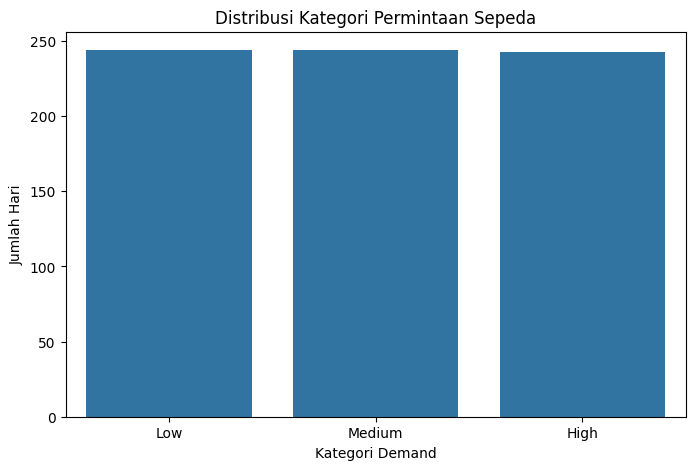

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=day_df, x='demand_category')

plt.title("Distribusi Kategori Permintaan Sepeda")
plt.xlabel("Kategori Demand")
plt.ylabel("Jumlah Hari")
plt.show()

### Binning Bedasarkan Suhu

Selain itu, dilakukan juga pengelompokan data suhu ke dalam beberapa kategori untuk melihat hubungan antara suhu dan tingkat permintaan penyewaan sepeda.

In [ ]:
# Membuat kategori suhu
day_df['temp_category'] = pd.cut(
    day_df['temp'],
    bins=3,
    labels=['Low Temp', 'Medium Temp', 'High Temp']
)

# Cek distribusi
day_df['temp_category'].value_counts()

,count
temp_category,
Medium Temp,297
High Temp,264
Low Temp,170


In [ ]:
pd.crosstab(day_df['temp_category'], day_df['demand_category'])

demand_category,Low,Medium,High
temp_category,,,
Low Temp,139,21,10
Medium Temp,93,103,101
High Temp,12,120,132


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Rata-rata penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah (weathersit = 1) dan menurun secara konsisten pada kondisi cuaca yang lebih buruk. Hal ini menunjukkan bahwa kondisi cuaca merupakan faktor utama yang memengaruhi tingkat penggunaan layanan bike sharing.
- **Conclusion pertanyaan 2:** Puncak penyewaan sepeda terjadi pada pukul 08.00 serta 16.00–18.00, yang mengindikasikan pola penggunaan yang berkaitan dengan aktivitas komuter (berangkat dan pulang kerja). Di luar jam tersebut, tingkat penyewaan relatif lebih rendah.
- **Conclusion pertanyaan 3:** Rata-rata penyewaan sepeda lebih tinggi pada hari kerja dibandingkan akhir pekan atau hari libur, yang menunjukkan bahwa sepeda lebih sering digunakan sebagai sarana transportasi rutin daripada untuk keperluan rekreasi.

**Rekomendasi Action Item:**
- **Optimasi operasional berdasarkan cuaca**
 Menyediakan lebih banyak sepeda saat kondisi cuaca cerah, serta mempertimbangkan strategi promosi pada kondisi cuaca kurang baik untuk menjaga tingkat penggunaan.
- **Manajemen ketersediaan pada jam sibuk**
Memastikan ketersediaan sepeda pada jam puncak (08.00 dan 16.00–18.00), serta melakukan redistribusi sepeda secara berkala untuk menghindari kekurangan unit.
- **Fokus pada hari kerja sebagai core demand**
Mengoptimalkan layanan pada hari kerja dengan memastikan distribusi sepeda merata di area strategis seperti perkantoran atau pusat aktivitas.
- **Meningkatkan penggunaan pada akhir pekan**
Mengembangkan strategi khusus seperti promo atau paket rekreasi untuk meningkatkan minat penggunaan sepeda pada akhir pekan.
- **Pemanfaatan analisis lanjutan (clustering & suhu)**
Menggunakan informasi kategori demand (Low, Medium, High) dan suhu untuk memprediksi potensi permintaan serta mendukung pengambilan keputusan operasional.